In [1]:
import sys
import gc

sys.path.append("../")
from explainerpfn.base import ExplainerPFN
from explainerpfn.train.synthetic_data import SyntheticDataGenerator
import torch
from torch import optim
from tqdm.auto import tqdm
import numpy as np

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
    # Total and free memory in bytes
    free, total = torch.cuda.mem_get_info()
    print(f"Total memory: {total / 1024**2:.2f}MB")
    print(f"Free memory: {free / 1024**2:.2f}MB")
else:
    print("No GPU available. Training will run on CPU.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GPU: Tesla V100-PCIE-32GB is available.
Total memory: 32501.12MB
Free memory: 32191.12MB


In [2]:
def read_data(path="../../synthetic_data_v4.pkl", sample_size=None, last_k=None, random_state=None, verbose=False):
    datasets = SyntheticDataGenerator(successor_as_target=True)
    datasets.load_data(path=path)
    
    # Keep only datasets with 50 features or less - for testing purposes
    desc = datasets.describe()
    desc = desc[((desc["n_train_samples"] * desc["n_features"]) < 70e3)&(desc["n_features"]<=45)]
    datasets_idxs = desc.index.tolist()
    
    # Get iterator for datasets
    data = list(zip(datasets.X_, datasets.y_pred_, datasets.explanations_))
    data = [data[i] for i in datasets_idxs]
    if last_k is not None:
        data = data[-last_k:]
    if sample_size is not None:
        rng = np.random.default_rng(random_state)
        data = [data[i] for i in rng.choice(len(data), size=sample_size, replace=False)]
        
    # Setup preprocessing for each dataset
    iter_ = tqdm(data, desc="Preprocessing") if verbose else data
    preprocessed_data = []
    for X_train, y_train, shap_train in iter_:
        # shap_train_normalized = shap_train.values / shap_train.values.std()
        # shap_train_normalized = shap_train_normalized / (y_train.std() / np.sqrt(X_train.shape[1]))

        _xai = ExplainerPFN(fit_mode="low_memory", random_state=random_state, device="cpu")
        _xai.fit(X_train.values, y_train)
        del _xai.model_
        for executor in _xai.executor_:
            del executor.model
            executor.use_torch_inference_mode(False)
        torch.cuda.empty_cache()

        preprocessed_data.append({
            'X': X_train.values,
            'y': y_train,
            'shap': shap_train.values,
            'executor_configs': _xai.executor_,  # Store preprocessing configs
            'feature_exp_std': shap_train.values.std()
        })

    return preprocessed_data

# Load model to train
# xai = ExplainerPFN(model_path="../../test_explainerpfn_model.ckp", random_state=42, device=device)

In [ ]:
# Training parameters
from copy import deepcopy


model_path="../../explainerpfn_model.ckp"
random_state = None
num_epochs = 10000
num_batches = 1
num_samples = 1024
save_interval = 32
step = 1


# Create a new ExplainerPFN for the feature we want to finetune
xai = ExplainerPFN(
    fit_mode="low_memory",
    model_path=model_path,
    random_state=random_state,
    device=device
)
xai._initialize_model_variables()
# xai.bardist_.to(device)
xai.model_.train()

# Setup optimizer - using Adam with a relatively small learning rate
# NOTE: Probably use lr=1e-5
# NOTE 2: Testing usage of cosine annealing scheduler
optimizer = optim.Adam(xai.model_.parameters(), lr=1e-6, weight_decay=1e-7)  # 1e-6)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
rng = np.random.default_rng(random_state)

# Loading all data a priori was causing OOM issues - loading periodically instead
data = read_data(sample_size=num_batches*step, random_state=random_state) # , last_k=50)

# Training loop
best_avg_loss = np.inf
losses = []
for epoch in tqdm(range(num_epochs), desc="Epochs"):
    optimizer.zero_grad()
    epoch_losses = []

    # Sample batch indices
    batch_idxs = rng.choice(len(data), size=num_batches, replace=True)

    # Sample batches - NOTE: Currently testing training per dataset
    # batch_idxs = rng.choice(len(data), size=num_batches, replace=True)

    # Collect logits and SHAP values from all batches
    # all_logits = []
    # all_shap_values = []
    # all_batch_losses = []

    # Process all batches
    for batch_idx in batch_idxs:
        # X_train, y_train, shap_train = data[batch_idx]
        batch = data[batch_idx]
        indices = rng.permutation(len(batch["X"]))

        # Get batch data
        X_batch = batch["X"][indices][-num_samples:]
        y_batch = batch["y"][indices][-num_samples:]
        shap_batch = batch["shap"][indices][-num_samples:]
        executor_configs = batch['executor_configs']

        batch_loss = 0
        for feature_idx in range(X_batch.shape[1]):
            # Reuse model, but change executor config
            xai.executor_ = executor_configs
            xai.executor_[feature_idx].model = xai.model_  # Ensure same model
            xai.executor_[feature_idx].use_torch_inference_mode(False)

            # print(f"[before forward] Free Mem: {torch.cuda.mem_get_info()[0] / 1024**2:.2f}MB")
            with torch.enable_grad():
                # xai.forward returns a tuple (first element are averaged logits across estimators)
                feature_logits, outputs, borders = xai.forward(
                    X_batch, y_batch, feature_idx=feature_idx, only_return_standard_out=True
                )
                for output in outputs:
                    output.cpu()
                del outputs, borders  # NOTE: borders is a numpy array
                feature_logits.cpu()
            # print(f"[after forward] Free Mem: {torch.cuda.mem_get_info()[0] / 1024**2:.2f}MB")

            # Get target SHAP values for this feature
            target_shap = torch.tensor(
                shap_batch[:, feature_idx] / batch['feature_exp_std'],
                dtype=torch.float32,
                device=xai.device_
            )

            # # Diagnostic on first epoch
            # if epoch == 0 and feature_idx == 0 and batch_idx == batch_idxs[0]:
            #     print(f"\n=== Scale Diagnostics ===")
            #     print(f"Raw SHAP range: [{shap_batch[:, feature_idx].min():.3f}, {shap_batch[:, feature_idx].max():.3f}]")
            #     print(f"Target SHAP (normalized) range: [{target_shap.min():.3f}, {target_shap.max():.3f}]")
            #     print(f"Model output range: [{feature_logits.min():.3f}, {feature_logits.max():.3f}]")
            #     print(f"feature_exp_std: {batch['feature_exp_std']:.3f}\n")

            # Compute loss for this feature
            feature_loss = xai.bardist_(feature_logits.cpu().T, target_shap.cpu()).mean()
            batch_loss += feature_loss
            
        # Average loss across features
        batch_loss = batch_loss / X_batch.shape[1]
        epoch_losses.append(batch_loss)

    # Backprop once per epoch
    total_loss = torch.stack(epoch_losses).mean()
    total_loss.backward()

    # del feature_logits, target_shap, X_batch, y_batch, shap_batch
    # print(f"[before garbage collection] Free Mem: {torch.cuda.mem_get_info()[0] / 1024**2:.2f}MB")
    torch.cuda.empty_cache()
    gc.collect()
    # print(f"[after garbage collection] Free Mem: {torch.cuda.mem_get_info()[0] / 1024**2:.2f}MB")
    
    # Gradient clipping
    total_grad_norm = 0
    for p in xai.model_.parameters():
        if p.grad is not None:
            total_grad_norm += p.grad.norm().item() ** 2
    total_grad_norm = total_grad_norm ** 0.5

    torch.nn.utils.clip_grad_norm_(xai.model_.parameters(), max_norm=1.0)

    optimizer.step()
    scheduler.step()

    # Record loss
    losses.append(total_loss.item())

    if epoch % step == 0:
        current_lr = optimizer.param_groups[0]['lr']
        free, total = torch.cuda.mem_get_info()
        print(
            f"Epoch {epoch}, "
            f"Loss: {total_loss.item():.3f}, "
            f"Grad Norm: {total_grad_norm:.3f}, "
            f"LR: {current_lr:.2e}, "
            f"Free Mem: {free / 1024**2:.2f}MB, "
            f"Total Mem: {total / 1024**2:.2f}MB"
        )

    # print(f"Epoch {epoch}, Loss: {total_loss.item():.3f}")

    if epoch % step == 0 or epoch == num_epochs - 1:
        del data
        data = read_data(
            # path="../../synthetic_data_v3.pkl", 
            sample_size=num_batches*step, 
            random_state=random_state
        ) # , last_k=50)

        # Garbage collection
        gc.collect()
        torch.cuda.empty_cache()

    last_avg_loss = np.mean(losses[-save_interval:])
    if epoch >= save_interval and best_avg_loss > last_avg_loss:
        best_avg_loss = last_avg_loss
        xai.save_foundation_model(f"../../explainerpfn_model_epoch_{epoch}.ckp")
        print("Saved model!")


print("Completed!")

Epochs:   0%|          | 0/10000 [00:00<?, ?it/s]

Epoch 0, Loss: 1.139, Grad Norm: 74.798, LR: 1.00e-06, Free Mem: 30415.12MB, Total Mem: 32501.12MB
Epoch 1, Loss: 0.094, Grad Norm: 124.521, LR: 1.00e-06, Free Mem: 30179.12MB, Total Mem: 32501.12MB
Epoch 2, Loss: 0.044, Grad Norm: 99.056, LR: 1.00e-06, Free Mem: 30155.12MB, Total Mem: 32501.12MB
Epoch 3, Loss: 0.433, Grad Norm: 22.696, LR: 1.00e-06, Free Mem: 30243.12MB, Total Mem: 32501.12MB
Epoch 4, Loss: 1.209, Grad Norm: 110.607, LR: 1.00e-06, Free Mem: 30275.12MB, Total Mem: 32501.12MB
Epoch 5, Loss: 0.992, Grad Norm: 83.100, LR: 1.00e-06, Free Mem: 30351.12MB, Total Mem: 32501.12MB
Epoch 6, Loss: 0.726, Grad Norm: 42.405, LR: 1.00e-06, Free Mem: 30373.12MB, Total Mem: 32501.12MB
Epoch 7, Loss: 0.616, Grad Norm: 52.660, LR: 1.00e-06, Free Mem: 30375.12MB, Total Mem: 32501.12MB
Epoch 8, Loss: 0.049, Grad Norm: 145.628, LR: 1.00e-06, Free Mem: 30259.12MB, Total Mem: 32501.12MB
Epoch 9, Loss: 0.904, Grad Norm: 59.391, LR: 1.00e-06, Free Mem: 30343.12MB, Total Mem: 32501.12MB
Epoch 1

In [ ]:
executor_configs[0].prepare_inference_data(X_batch)

In [4]:
executor_configs[0].X_trains[0].shape


(803, 23)

In [11]:
from sklearn.linear_model import LinearRegression
import numpy as np
model = LinearRegression()
model.fit(np.arange(len(losses)).reshape(-1, 1), np.array(losses))
trendline = model.predict(np.arange(len(losses)).reshape(-1, 1))
model.coef_, model.intercept_

(array([-2.99340017e-05]), np.float64(0.7724780661019891))

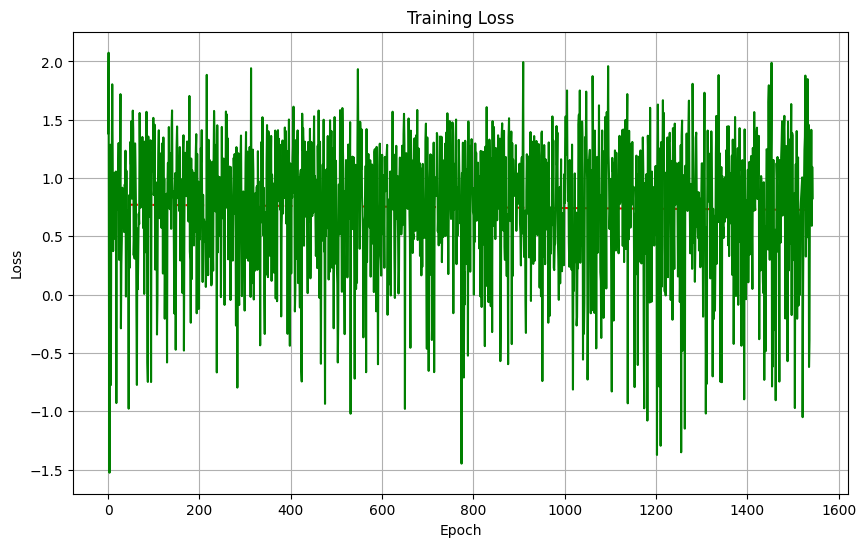

In [12]:
import matplotlib.pyplot as plt

# Plot the training loss curve
plt.figure(figsize=(10, 6))
# plt.plot(losses)
plt.plot(trendline, linestyle='--', color='red', label='Trendline')
window_size = 1
plt.plot(np.convolve(losses, np.ones(window_size) / window_size, mode="valid"), linestyle='-', color='green', label="moving avg")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [ ]:

losses = input()
epochs = [int(x.split(", Loss: ")[0].strip()) for x in losses.split("Epoch") if x]
losses = [float(x.split(", Loss: ")[-1].strip()) for x in losses.split("Epoch") if x]

plt.plot(epochs, losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [ ]:
[int(x.split(", Loss: ")[0].strip()) for x in losses.split("Epoch") if x]

In [ ]:
# _xai.bardist_(feature_logits.T, batch_shap_tensor)
feature_logits
batch_shap_tensor

In [ ]:
feature_logits.shape